# 期現套利 HBT：每日持久化跨日 Runner

## Goal

這個 Notebook 是位於 root `notebooks/` 的新版 full-market pipeline 薄 runner。它透過 `future_spot` strategy adapter 使用 neutral `hftbacktest_slim` API，預設由 Slim Rust engine 直接讀取 Arrow compact BBO cache；Reference HftBacktest 保留為回歸 oracle 與不支援模式的 fallback。日期依序處理、同日 pairs 使用同一個常駐 worker pool，未平倉部位以原期貨合約帶入下一日。

`report_mode='summary'` 會在每個日期完成後，把 summary、trades、market、latency、entry/exit、carry 與 errors 原子發布到 `output/core/dates/trade_date=YYYY-MM-DD/`。年度大型明細不留在記憶體；重新執行時只重用 manifest、資料 identity 與 carry chain 全部驗證成功的連續日期。

In [14]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

CURRENT_DIR = Path.cwd().resolve()
REPOSITORY_ROOT = next((
    candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
    if (candidate / 'future_spot').is_dir() and (candidate / 'hftbacktest_slim').is_dir()
), None)
if REPOSITORY_ROOT is None:
    raise FileNotFoundError('Open this notebook from inside the hftbacktest repository')
print(f'REPOSITORY_ROOT: {REPOSITORY_ROOT}')
FUTURE_SPOT_ROOT = REPOSITORY_ROOT / 'future_spot'

from hftbacktest_slim import (
    COMPACT_BUILDER_VERSION,
    COMPACT_SCHEMA_VERSION,
    SLIM_ENGINE_VERSION,
    __version__ as SLIM_PACKAGE_VERSION,
)
repository_path = str(REPOSITORY_ROOT)
if repository_path not in sys.path:
    sys.path.insert(0, repository_path)
from future_spot.test.backtest_config import default_notebook_args
from future_spot.test.backtest_pipeline import run_backtest_pipeline
from future_spot.test.report_tables import build_report_tables
from future_spot.test.report_plots import save_report_plots
from scripts.daily_result_store import DAILY_RESULT_SCHEMA_VERSION, DailyResultStore
from scripts.io_utils import read_csv_if_exists

REPOSITORY_ROOT: /home/zoufuc/hftbacktest


## Setup

### 1. 設定日期、延遲、資金與輸出模式

請先在 repository root 執行 `python3 -m pip install -e ./hftbacktest_slim`。Notebook 會由 kernel environment 載入已安裝的 neutral package；setup cell 只加入經驗證的 repository root，以載入尚未獨立發佈的 `future_spot` 與 `scripts` packages，不會加入 `hftbacktest_slim/src` 或任何舊 slim wrapper 路徑。

第一次執行會逐日建立結果分區；同一組結果定義再次執行時會驗證並續跑。若程式、資料或參數 identity 改變，請使用新的 `output_dir`，不要覆蓋舊研究結果。

In [15]:
# # 這 8 個到期殘倉 run 會從 HBT、交易、績效與資金重播中刪除。
# EXCLUDED_RUN_KEYS = {
#     '2026-04-15::1802_KUFD6',
#     '2026-05-20::6173_PKFE6',
#     '2026-07-15::2340_FYFG6',
#     '2026-07-15::2408_CYFG6',
#     '2026-07-15::3714_QBFG6',
#     '2026-07-15::4919_REFG6',
#     '2026-07-15::5371_NMFG6',
#     '2026-07-15::6257_MQFG6',
#     '2026-07-15::3037_IRFG6'
# }

start_date = '2026-09-07'
end_date = '2026-09-07'

args = default_notebook_args(
    start_date=start_date,
    end_date=end_date,
    output_dir=CURRENT_DIR / 'output' / f'hbt_daily_full_market_{start_date}_{end_date}',
    engine='slim',
    market_data_cache='compact',
    compact_cache_root= CURRENT_DIR / 'output' / 'compact_bbo_v1',
    compact_cache_compression='lz4',
    carry_positions=True,
    total_capital=50_000_000.0,
    futures_margin_rate=0.20,
    spot_equity_rate=0.40,
    leverage=False,             # False：期貨與現股皆按 100% 自有資金
    future_order_latency_ms=1.0,
    future_response_latency_ms=1.0,
    future_feed_latency_offset_ms=0.0,
    spot_order_latency_ms=1.0,
    spot_response_latency_ms=35.0,
    spot_feed_latency_offset_ms=0.0,
    low_memory_reports=True,
    report_mode='summary',      # 啟用每日 Parquet、bounded memory 與 verified resume
    report_chunk_rows=25_000,
    continue_on_error=False,
    post_first_feed_wait='spot',
    post_first_feed_timeout_ms=5000.0,
    rebuild_hbt_results=False,
    # excluded_run_keys=sorted(EXCLUDED_RUN_KEYS),
)

PLOT_EXCLUDED_DATES = tuple(args.excluded_dates)
print(f'Output: {args.output_dir}')
print(f'Engine/cache: {args.engine} / {args.market_data_cache}')
print(f'Compact cache: {args.compact_cache_root}')
print(f'Slim package/engine: {SLIM_PACKAGE_VERSION} / {SLIM_ENGINE_VERSION}')
print(f'Compact schema/builder: {COMPACT_SCHEMA_VERSION} / {COMPACT_BUILDER_VERSION}')
print(f'Daily result schema: {DAILY_RESULT_SCHEMA_VERSION}')

Output: /home/zoufuc/hftbacktest/notebooks/output/hbt_daily_full_market_2026-09-07_2026-09-07
Engine/cache: slim / compact
Compact cache: /home/zoufuc/hftbacktest/notebooks/output/compact_bbo_v1
Slim package/engine: 0.3.0 / rust-0.2.0
Compact schema/builder: bbo_v1 / 2
Daily result schema: 1


## Steps

### 2. 執行或續跑，顯示各階段耗時，並驗證每日 manifest、carry 與錯誤稽核

完整 timing audit 會保存為 `stage_timings.csv`。Notebook 顯示 pipeline 階段、各 stage 統計，以及逐交易日耗時；`date_total` 包含該日所有子階段，不應再與子階段相加。

In [16]:
artifacts = run_backtest_pipeline(args)

stage_timings = artifacts.frame('stage_timings').copy()
stage_timings['elapsed_seconds'] = pd.to_numeric(stage_timings['elapsed_seconds'], errors='coerce')
pipeline_timings = stage_timings.loc[stage_timings['mode'].eq('pipeline')].copy()
timing_summary = (
    stage_timings.loc[stage_timings['stage'].ne('date_total')]
    .groupby(['mode', 'stage'], dropna=False)['elapsed_seconds']
    .agg(calls='size', total_seconds='sum', mean_seconds='mean', max_seconds='max')
    .reset_index()
    .sort_values('total_seconds', ascending=False)
)
daily_timings = (
    stage_timings.loc[stage_timings['trade_date'].notna()]
    .pivot_table(index=['trade_date', 'mode'], columns='stage', values='elapsed_seconds', aggfunc='sum')
    .reset_index()
)

print(f'Stage timing CSV: {artifacts.output_dir / "stage_timings.csv"}')
display(pipeline_timings[['stage', 'elapsed_seconds', 'pair_count']])
display(timing_summary)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(daily_timings)
conversion_audit = artifacts.frame('conversion_status')
cache_audit_columns = [column for column in (
    'trade_date', 'compact_cache_state', 'compact_build_invocation_scan_count',
) if column in conversion_audit.columns]
if cache_audit_columns:
    display(conversion_audit[cache_audit_columns].drop_duplicates().sort_values('trade_date'))
result_store = DailyResultStore(artifacts.output_dir / 'core')

manifest_rows = []
for trade_date in artifacts.trade_dates:
    manifest = result_store.validate(trade_date)
    payload = manifest.payload
    manifest_rows.append({
        'trade_date': trade_date,
        'schema_version': payload['schema_version'],
        'engine': payload.get('metadata', {}).get('engine'),
        'time_in_force_semantics': payload.get('metadata', {}).get('time_in_force_semantics'),
        'run_keys': len(payload.get('run_keys', [])),
        'summary_rows': payload.get('tables', {}).get('summary', {}).get('rows', 0),
        'trade_rows': payload.get('tables', {}).get('trades', {}).get('rows', 0),
        'error_rows': payload.get('tables', {}).get('run_errors', {}).get('rows', 0),
        'manifest': str(manifest.path),
    })
daily_manifest_audit = pd.DataFrame(manifest_rows)
if len(daily_manifest_audit) != len(artifacts.trade_dates):
    raise RuntimeError('每日結果不是完整且連續的已驗證日期序列')

display(daily_manifest_audit.head(20))
display(artifacts.frame('summary').head(20))
entry_exit_index = read_csv_if_exists(artifacts.output_dir / 'entry_exit_index.csv')
display(entry_exit_index.head(20))

carry_status = artifacts.frame('position_carry_status')
if not carry_status.empty:
    display(carry_status.loc[carry_status['universe_source'].ne('selected')].head(30))
    expiry_violations = carry_status.loc[carry_status['status'].eq('expiry_position_remaining')].copy()
    if not expiry_violations.empty:
        display(expiry_violations)
        raise RuntimeError(f'期貨到期日仍有殘倉：{len(expiry_violations)} 筆')

run_errors = read_csv_if_exists(artifacts.output_dir / 'run_errors.csv')
print(f'run_errors.csv rows: {len(run_errors):,}')
if not run_errors.empty:
    display(run_errors.head(100))

for frame_name in ('summary', 'position_carry_status'):
    frame = artifacts.frame(frame_name)
    leaked = frame.loc[frame['run_key'].astype(str).isin(EXCLUDED_RUN_KEYS)] if not frame.empty else frame
    if not leaked.empty:
        raise RuntimeError(f'{frame_name} 仍含已排除 run_key：{sorted(leaked.run_key.unique())}')
for trade_date in artifacts.trade_dates:
    trades_for_date = result_store.load_table(trade_date, 'trades')
    if not trades_for_date.empty:
        leaked = trades_for_date.loc[trades_for_date['run_key'].astype(str).isin(EXCLUDED_RUN_KEYS)]
        if not leaked.empty:
            raise RuntimeError(f'trades 仍含已排除 run_key：{sorted(leaked.run_key.unique())}')

print('每日 manifest、跨日 carry、排除 run_key 與錯誤稽核完成。')

Stage timing CSV: /home/zoufuc/hftbacktest/notebooks/output/hbt_daily_full_market_2026-09-07_2026-09-07/stage_timings.csv


,stage,elapsed_seconds,pair_count
0,prepare_args,0.000079,0
1,select_trade_dates,0.006429,0
2,build_daily_pair_records,4.442757,121
3,execute_or_resume_hbt,214.414169,121
12,persist_audit_frames,0.005697,121
13,write_backtest_manifest,6.985628,121
14,entry_exit_handoff,0.000224,121
15,pipeline_total,225.857512,121


,mode,stage,calls,total_seconds,mean_seconds,max_seconds
9,pipeline,pipeline_total,1,225.857512,225.857512,225.857512
7,pipeline,execute_or_resume_hbt,1,214.414169,214.414169,214.414169
3,executed,event_data,1,187.705774,187.705774,187.705774
13,resume_check,daily_identity_validation,1,12.519614,12.519614,12.519614
4,executed,pair_matching,1,8.506195,8.506195,8.506195
12,pipeline,write_backtest_manifest,1,6.985628,6.985628,6.985628
2,executed,event_audit,1,4.547124,4.547124,4.547124
5,pipeline,build_daily_pair_records,1,4.442757,4.442757,4.442757
14,run,compatibility_csv_stream,1,0.519502,0.519502,0.519502
0,executed,carry_and_entry_exit,1,0.429146,0.429146,0.429146


stage,trade_date,mode,carry_and_entry_exit,daily_identity_validation,daily_result_publish,date_total,event_audit,event_data,pair_matching
0,2026-09-07,executed,0.429146,NaN,0.117486,213.825442,4.547124,187.705774,8.506195
1,2026-09-07,resume_check,NaN,12.519614,NaN,NaN,NaN,NaN,NaN


,trade_date,compact_cache_state,compact_build_invocation_scan_count
0,2026-09-07,miss,2


...

,trade_date,run_key,pair_name,spot_symbol,future_symbol,rows,filled_pairs,second_leg_failures,flatten_count,realized_pnl,...,post_first_feed_poll_ns,spot_order_latency_ns,future_order_latency_ns,spot_response_latency_ns,future_response_latency_ns,spot_feed_latency_offset_ns,future_feed_latency_offset_ns,strategy_engine,scan_calls,python_decisions
0,2026-09-07,2026-09-07::1303_CAFI6,1303_CAFI6,1303,CAFI6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,python,0,15899
1,2026-09-07,2026-09-07::2002_CBFI6,2002_CBFI6,2002,CBFI6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,python,0,15893
2,2026-09-07,2026-09-07::2881_CEFI6,2881_CEFI6,2881,CEFI6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,python,0,15882
3,2026-09-07,2026-09-07::1301_CFFI6,1301_CFFI6,1301,CFFI6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,python,0,15891
4,2026-09-07,2026-09-07::2324_CGFI6,2324_CGFI6,2324,CGFI6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,python,0,15899
5,2026-09-07,2026-09-07::2409_CHFI6,2409_CHFI6,2409,CHFI6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,python,0,15757
6,2026-09-07,2026-09-07::2880_CJFI6,2880_CJFI6,2880,CJFI6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,python,0,15884
7,2026-09-07,2026-09-07::2882_CKFI6,2882_CKFI6,2882,CKFI6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,python,0,15880
8,2026-09-07,2026-09-07::2886_CLFI6,2886_CLFI6,2886,CLFI6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,python,0,15883
9,2026-09-07,2026-09-07::2887_CMFI6,2887_CMFI6,2887,CMFI6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,python,0,15890


,trade_date,run_key,pair_name,rows,entry_signal_rows,entry_execution_rows,exit_execution_rows
0,2026-09-07,2026-09-07::1303_CAFI6,1303_CAFI6,0,0,0,0
1,2026-09-07,2026-09-07::2002_CBFI6,2002_CBFI6,0,0,0,0
2,2026-09-07,2026-09-07::2881_CEFI6,2881_CEFI6,0,0,0,0
3,2026-09-07,2026-09-07::1301_CFFI6,1301_CFFI6,0,0,0,0
4,2026-09-07,2026-09-07::2324_CGFI6,2324_CGFI6,0,0,0,0
5,2026-09-07,2026-09-07::2409_CHFI6,2409_CHFI6,0,0,0,0
6,2026-09-07,2026-09-07::2880_CJFI6,2880_CJFI6,0,0,0,0
7,2026-09-07,2026-09-07::2882_CKFI6,2882_CKFI6,0,0,0,0
8,2026-09-07,2026-09-07::2886_CLFI6,2886_CLFI6,0,0,0,0
9,2026-09-07,2026-09-07::2887_CMFI6,2887_CMFI6,0,0,0,0


,trade_date,run_key,pair_name,spot_symbol,future_symbol,universe_source,carried_from_date,initial_quantity,initial_direction,final_quantity,final_direction,expiry_date,is_expiry_date,carry_to_next_date,status


run_errors.csv rows: 0


NameError: name 'EXCLUDED_RUN_KEYS' is not defined

## Results

### 3. 以 bounded CSV chunks 產生資金與績效報表

大型明細已在日期邊界釋放；報表從每日分區串流產生的 compatibility CSV 讀取，不會重跑 HBT。

In [ ]:
reports = build_report_tables(artifacts)
display(reports.frame('symbol_profit').head(30))
display(reports.frame('failure_overview'))
display(reports.frame('capital_constraint_summary'))
display(reports.frame('daily_capital_constraint').tail(20))
print(f'Report CSV directory: {reports.output_dir}')

,spot_symbol,trade_days,pair_names,estimated_profit,avg_daily_profit,filled_pairs,second_leg_failures,flatten_count,final_quantity_abs
0,2455,4,1,250092.524,62523.1310,8,1,0,0.0
1,3037,4,1,2603.506,650.8765,2,0,0,0.0
2,1303,5,1,0.000,0.0000,0,0,0,0.0
3,1301,5,1,0.000,0.0000,0,0,0,0.0
4,1101,1,1,0.000,0.0000,0,0,0,0.0
5,1717,4,1,0.000,0.0000,0,0,0,0.0
6,1718,1,1,0.000,0.0000,0,0,0,0.0
7,1802,5,1,0.000,0.0000,0,0,0,0.0
8,2301,4,1,0.000,0.0000,0,0,0,0.0
9,2313,5,1,0.000,0.0000,0,0,0,0.0


,pairs_with_summary_failures,failure_trade_rows,market_window_rows,trade_dates,pair_names,flatten_count
0,2,2,0,2,2,0.0


,total_capital,futures_margin_rate,spot_equity_rate,effective_futures_margin_rate,effective_spot_equity_rate,leverage,carry_positions,futures_capital_limit,spot_capital_limit,matched_notional_limit,...,accepted_exits,discarded_open_lots,ending_open_lot_days,capital_filtered_realized_pnl,capital_filtered_realized_roi,peak_spot_capital,peak_futures_capital,peak_total_capital,peak_capital_utilization,replay_scope
0,50000000.0,0.2,0.4,1.0,1.0,False,True,25000000.0,25000000.0,25000000.0,...,5,0,0,256696.03,0.005134,3903556.898,4190000.0,8093556.898,0.161871,continuous_position_candidate_replay


,trade_date,accepted_entries,rejected_entries,accepted_exits,ignored_unmatched_exits,discarded_open_lots,ending_open_lots,realized_pnl,ending_spot_capital,ending_futures_capital,ending_total_capital,peak_spot_capital,peak_futures_capital,peak_total_capital,peak_capital_utilization
0,2026-09-02,1,0,1,0,0,0,2603.506,0.000000e+00,0.0,0.000000e+00,1960782.040,1978000.0,3938782.040,0.078776
1,2026-09-04,4,0,4,0,0,0,254092.524,1.164153e-10,0.0,1.164153e-10,3903556.898,4190000.0,8093556.898,0.161871


Report CSV directory: /home/zoufuc/hftbacktest/notebooks/output/hbt_daily_full_market_20260901_20260907_slim_compact_acc/reports


## 4. 儲存 PNG 圖表

Plot excluded dates: 2026-04-23, 2026-05-04, 2026-05-19, 2026-06-24, 2026-07-01, 2026-07-22, 2026-07-27
Plot exclusion audit: /home/zoufuc/hftbacktest/notebooks/output/hbt_daily_full_market_20260901_20260907_slim_compact_acc/figures/plot_exclusions.csv
portfolio_overview: /home/zoufuc/hftbacktest/notebooks/output/hbt_daily_full_market_20260901_20260907_slim_compact_acc/figures/portfolio_overview.png


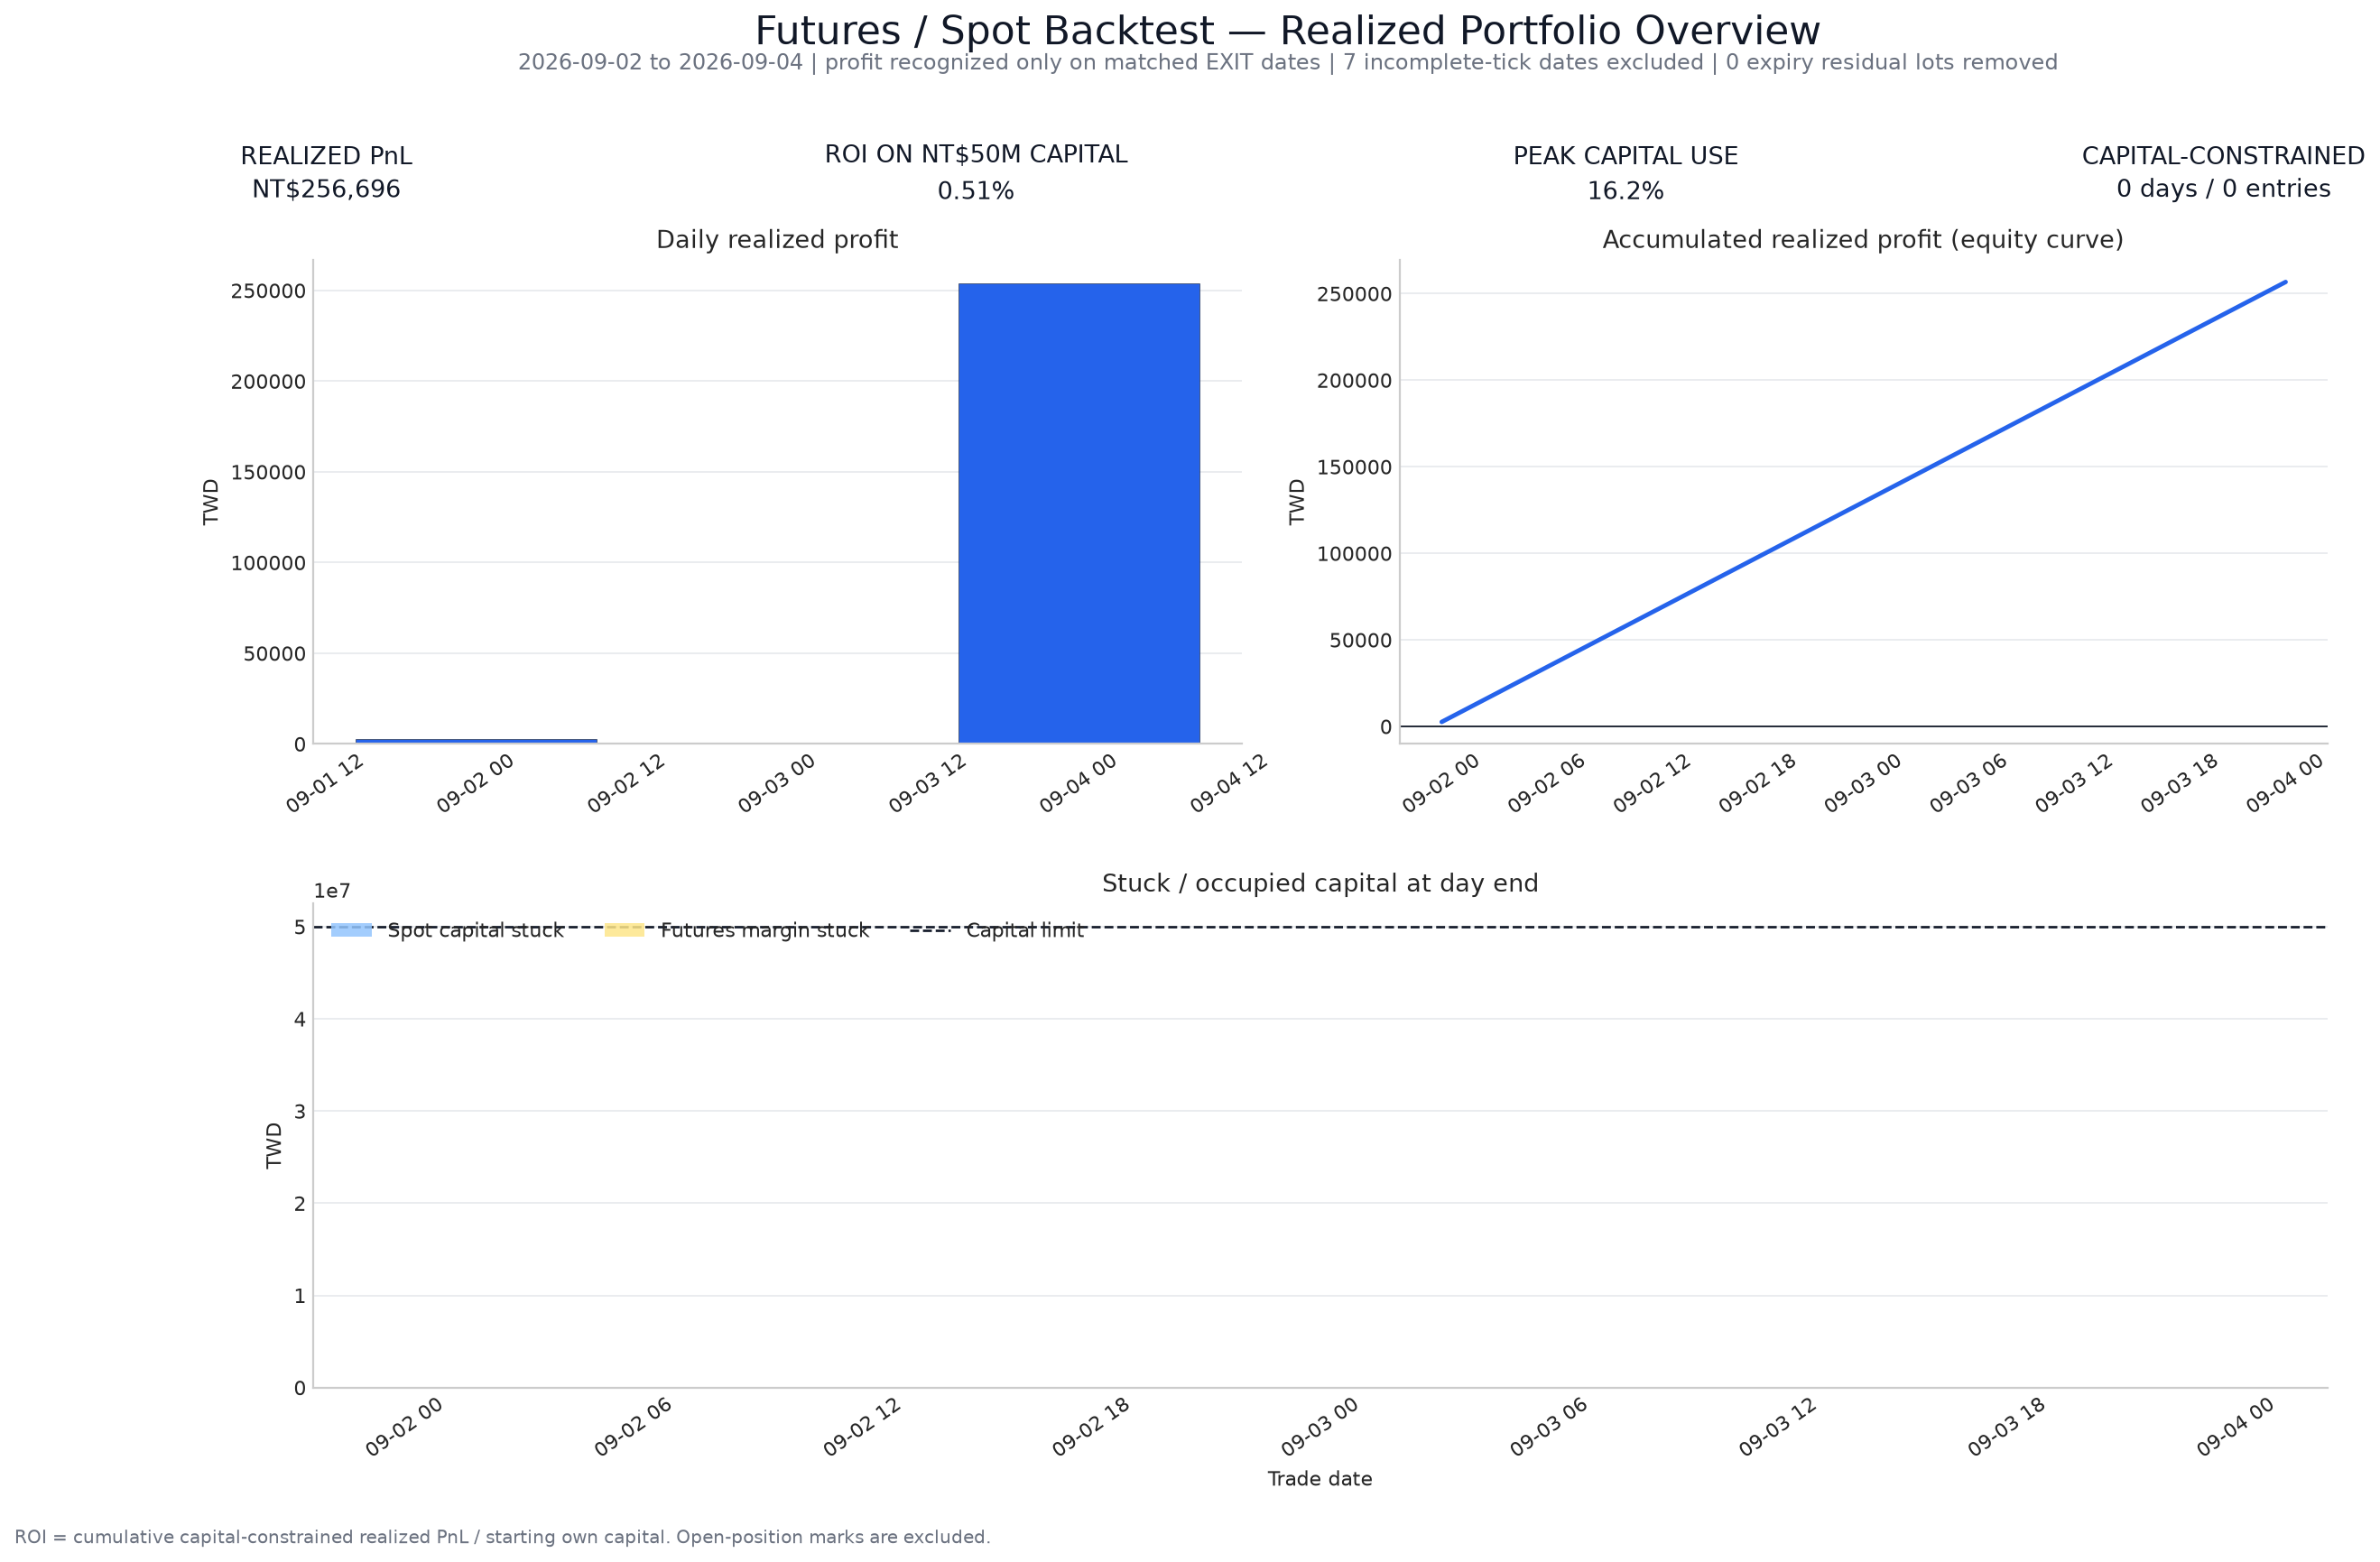

performance_overview: /home/zoufuc/hftbacktest/notebooks/output/hbt_daily_full_market_20260901_20260907_slim_compact_acc/figures/performance_overview.png


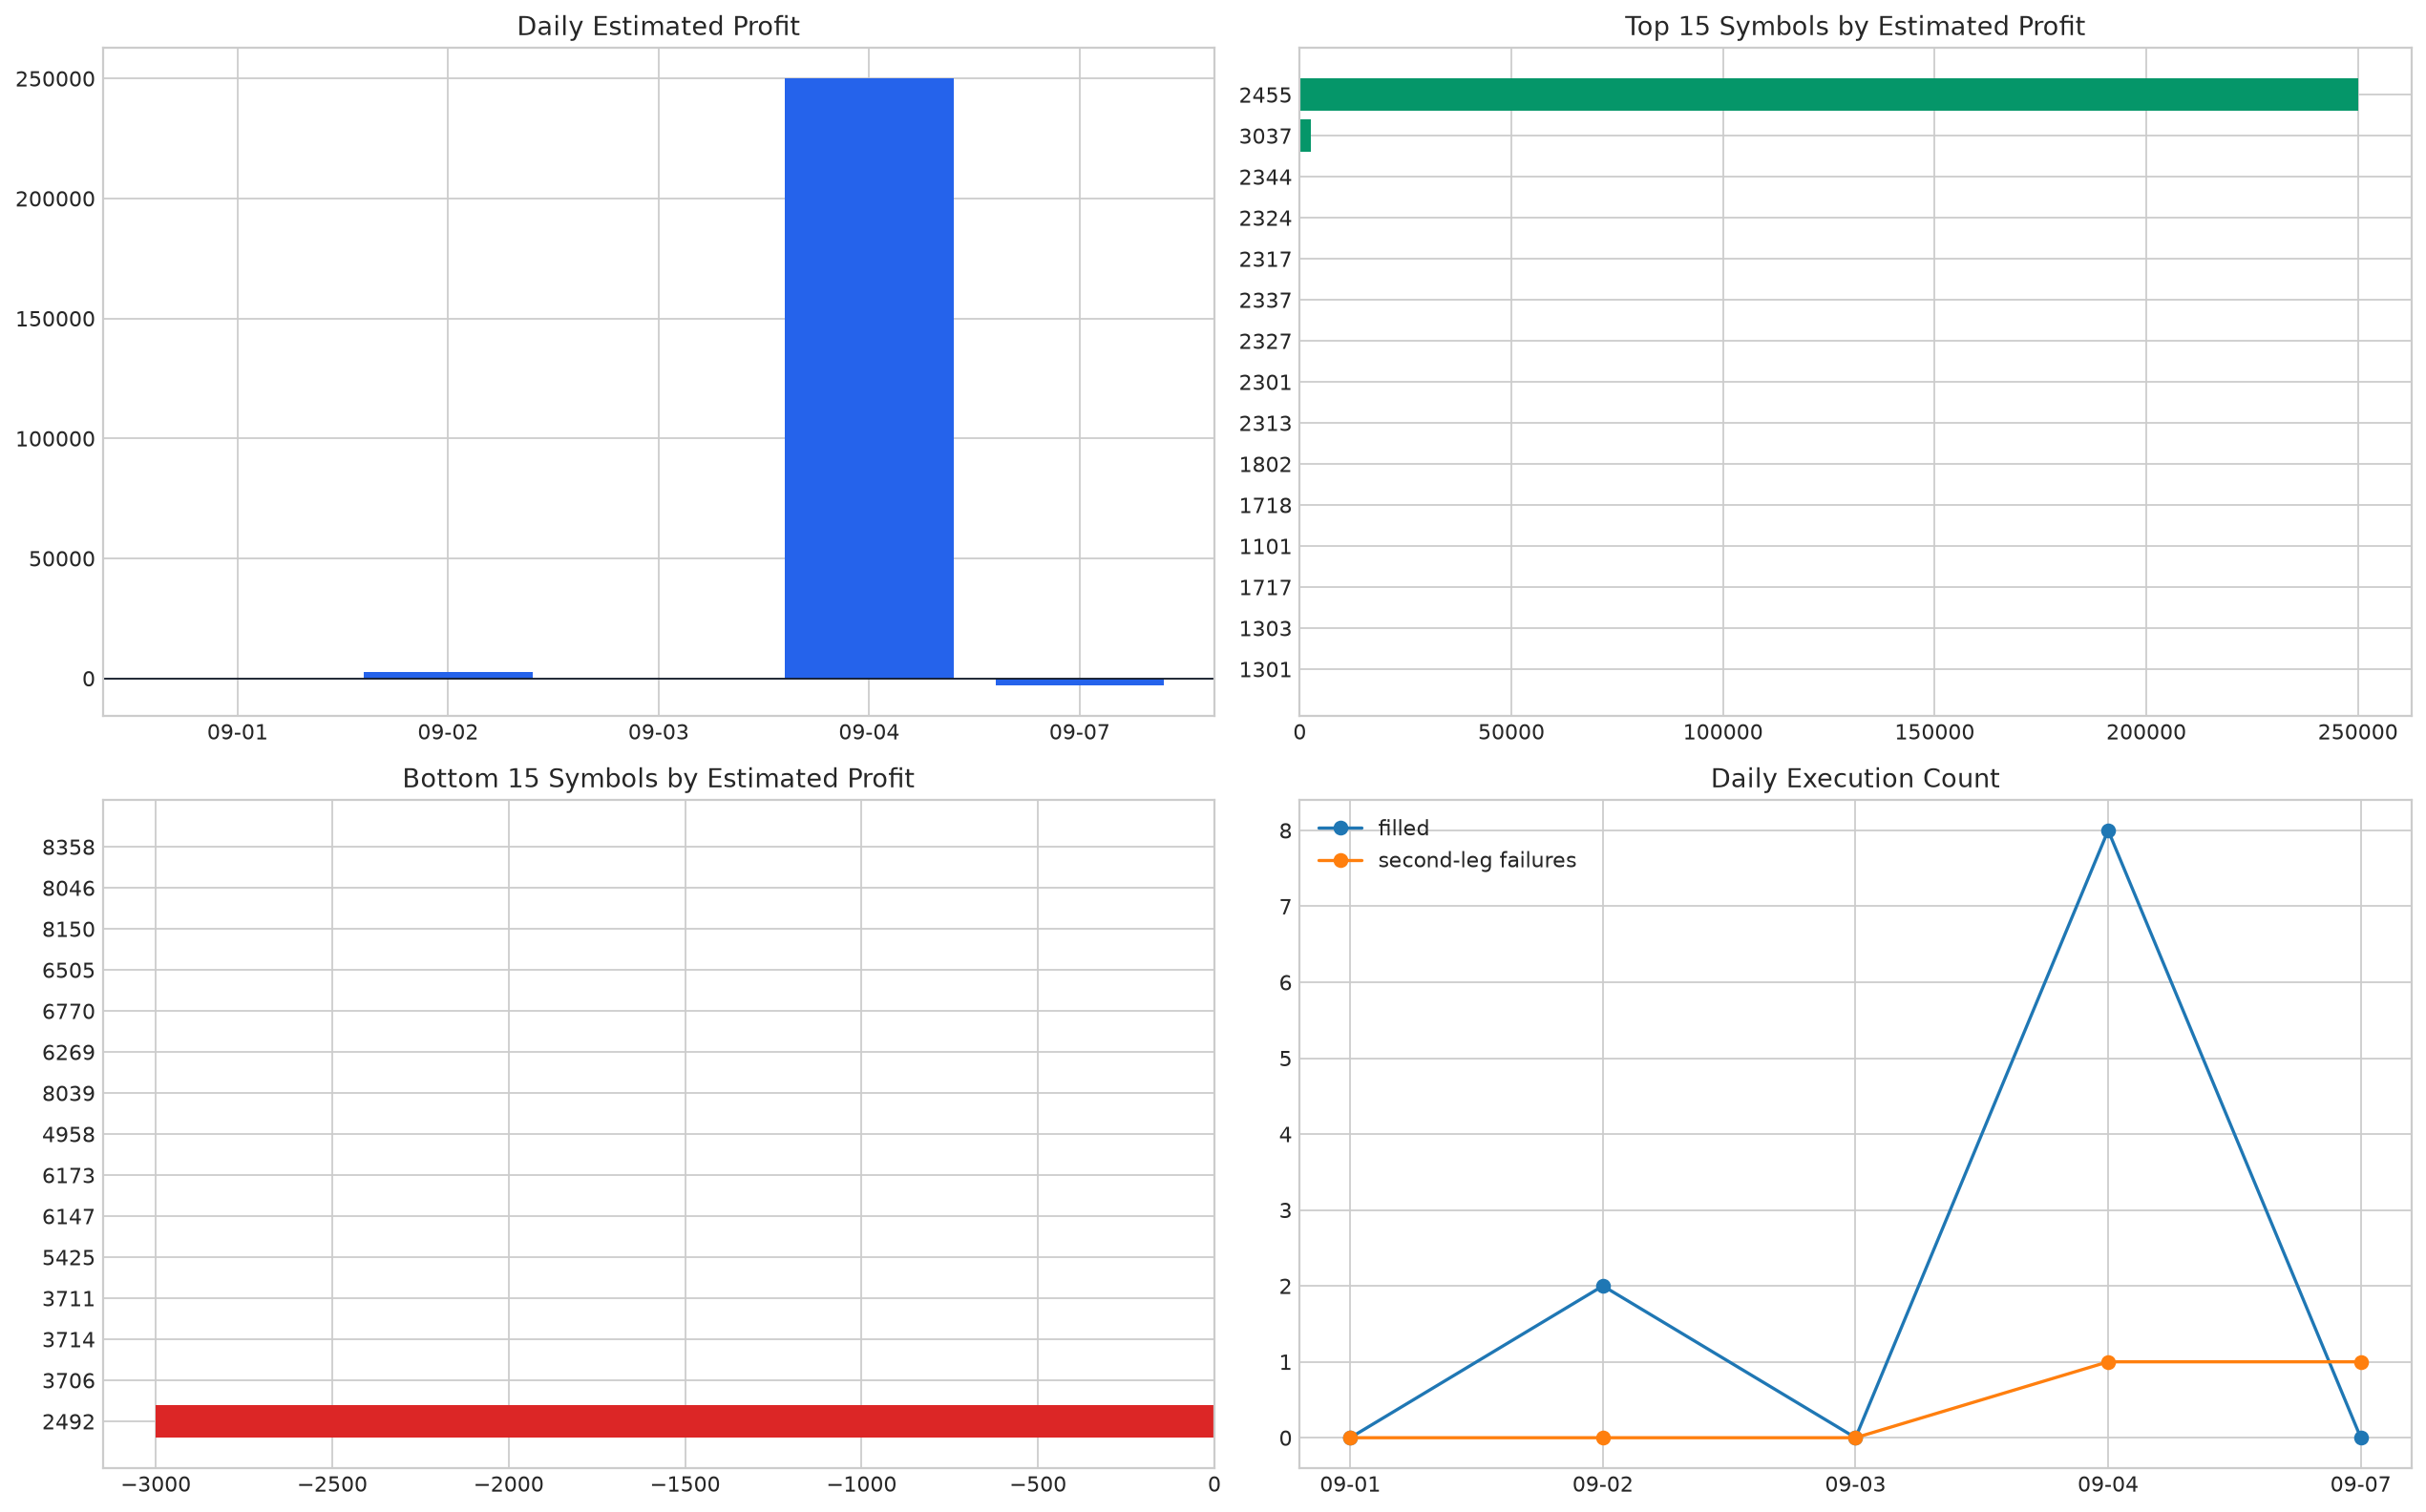

pair_profit_scatter: /home/zoufuc/hftbacktest/notebooks/output/hbt_daily_full_market_20260901_20260907_slim_compact_acc/figures/pair_profit_scatter.png


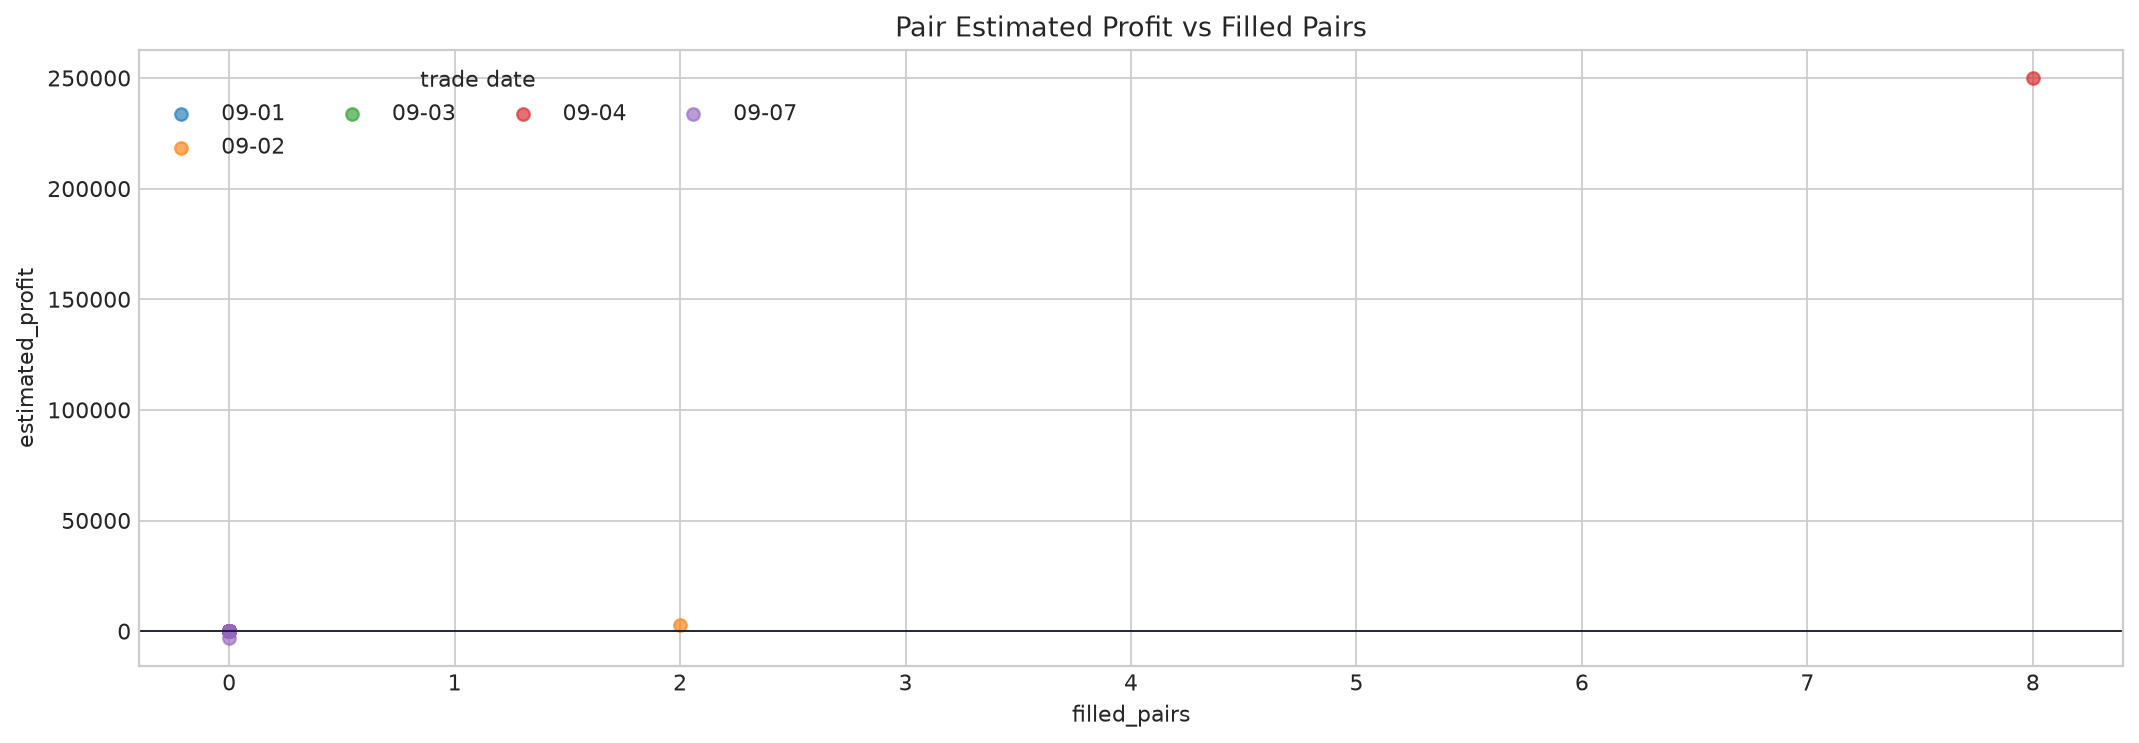

stuck_cash: /home/zoufuc/hftbacktest/notebooks/output/hbt_daily_full_market_20260901_20260907_slim_compact_acc/figures/stuck_cash.png


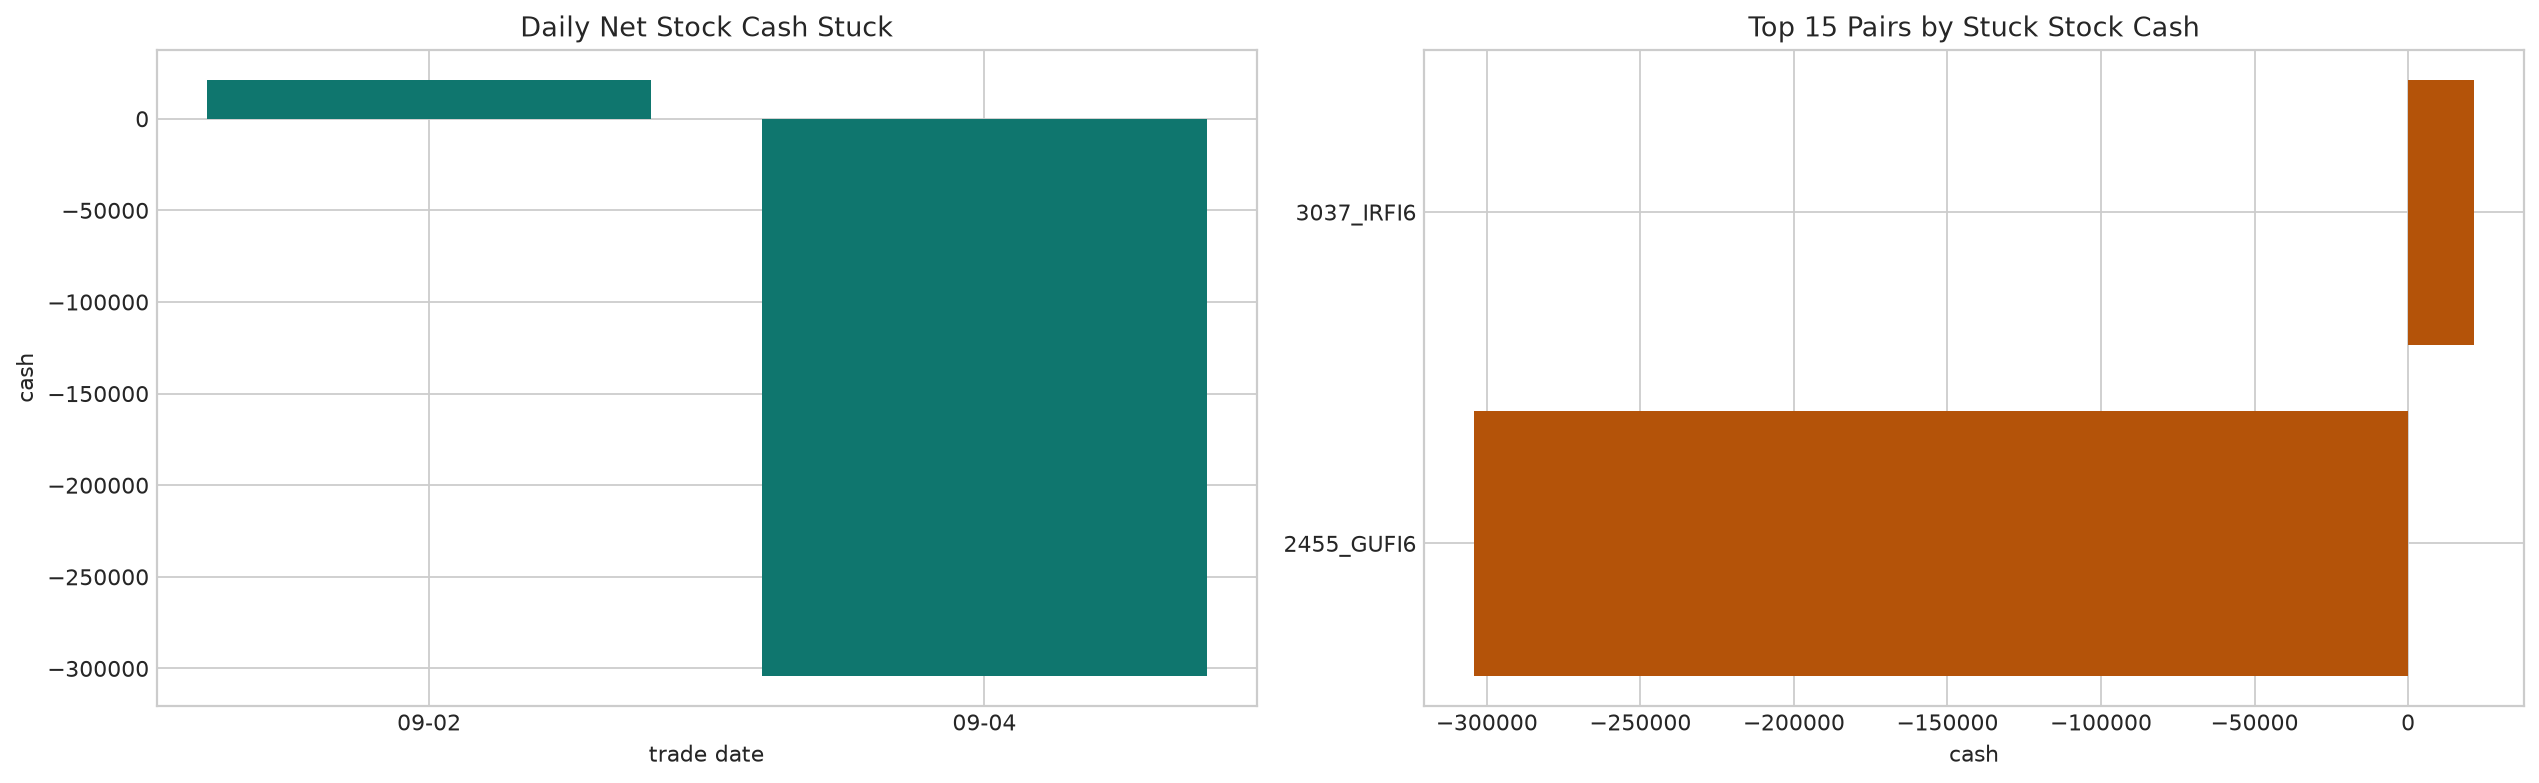

latency_timelines: /home/zoufuc/hftbacktest/notebooks/output/hbt_daily_full_market_20260901_20260907_slim_compact_acc/figures/latency_timelines.png


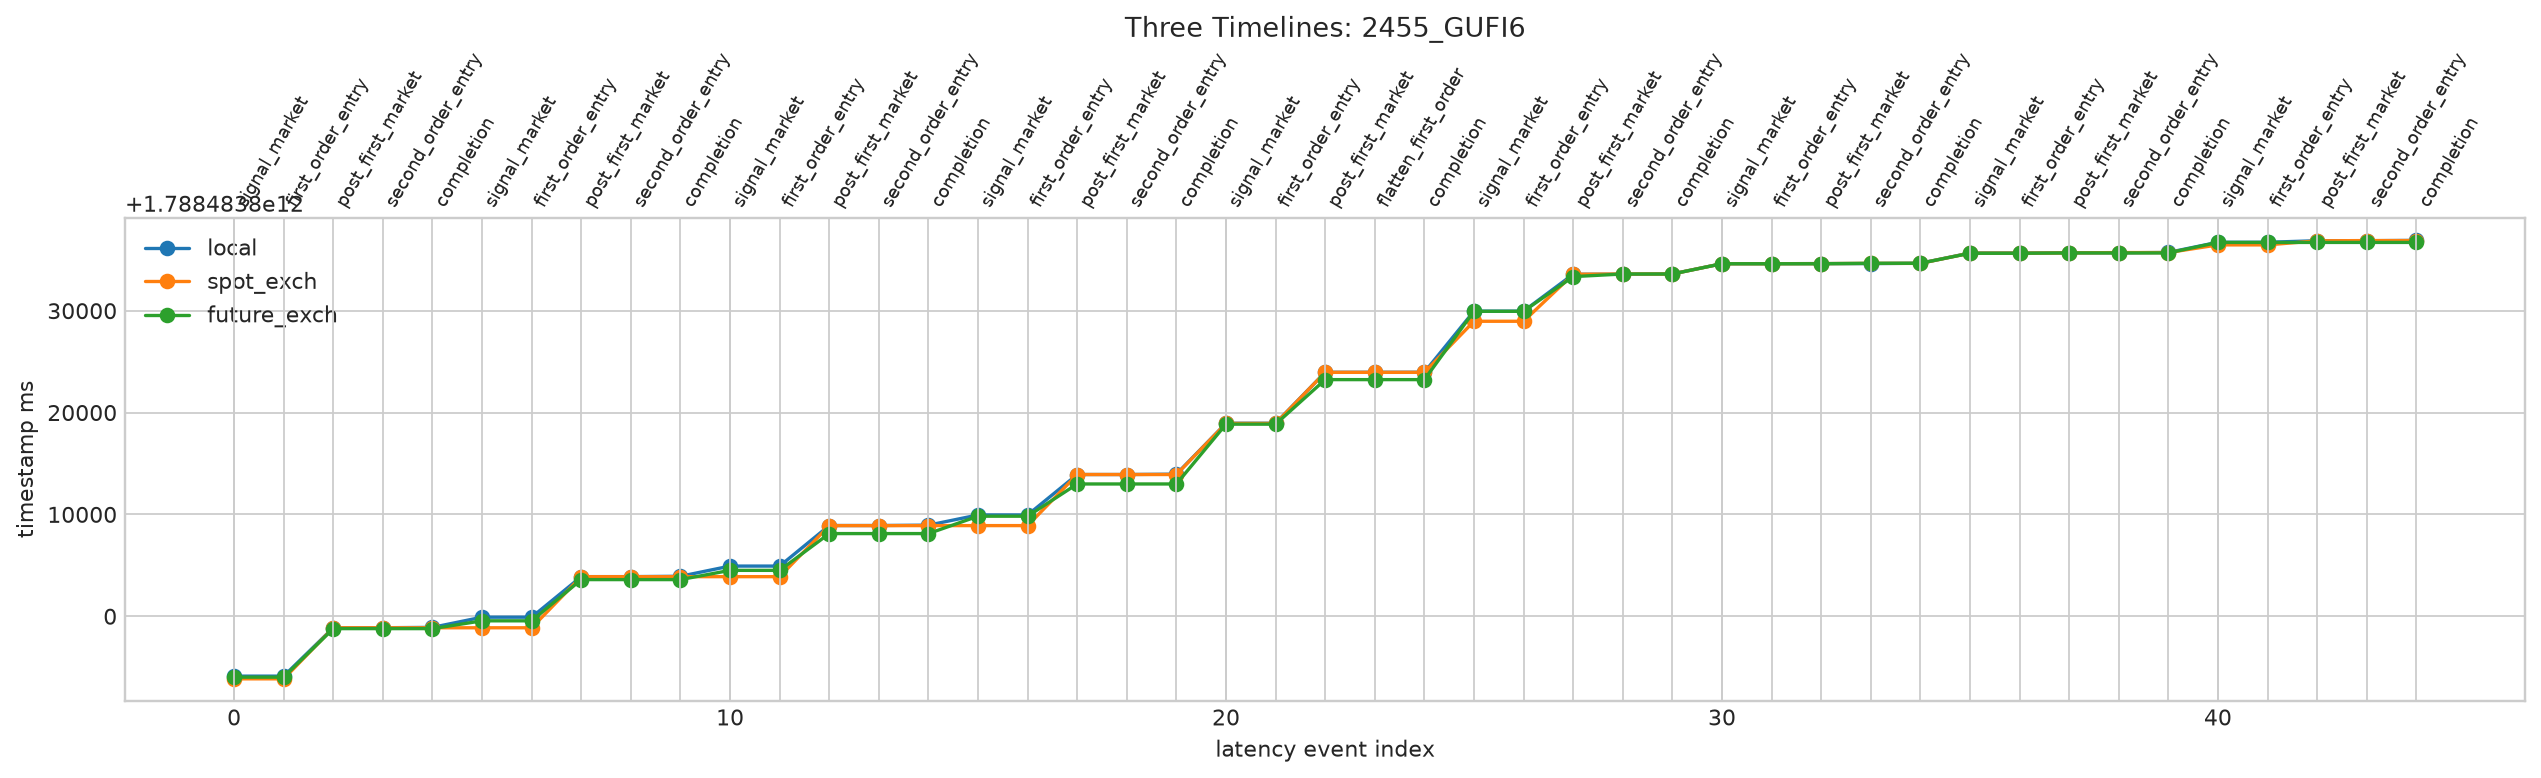

In [ ]:
figure_paths = save_report_plots(artifacts, reports, excluded_dates=PLOT_EXCLUDED_DATES)
print(f'Plot excluded dates: {", ".join(PLOT_EXCLUDED_DATES)}')
print(f'Plot exclusion audit: {artifacts.output_dir / "figures" / "plot_exclusions.csv"}')
for name, path in figure_paths.items():
    print(f'{name}: {path}')
    display(Image(filename=str(path)))

## Checks

### 5. 選擇性逐 pair 檢查

逐 pair 明細以 chunks 掃描 compatibility CSV，只保留選定 pair 的前幾筆，不重新載入整年度資料。

In [ ]:
def selected_pair_rows(csv_path, pair_name, limit, chunk_rows=25_000):
    if pair_name is None or not csv_path.exists() or csv_path.stat().st_size == 0:
        return pd.DataFrame()
    selected = []
    try:
        chunks = pd.read_csv(csv_path, chunksize=chunk_rows, low_memory=False)
        for chunk in chunks:
            if 'pair_name' not in chunk.columns:
                return pd.DataFrame()
            rows = chunk.loc[chunk['pair_name'].astype(str).eq(str(pair_name))]
            if not rows.empty:
                selected.append(rows.head(limit - sum(len(frame) for frame in selected)))
            if sum(len(frame) for frame in selected) >= limit:
                break
    except pd.errors.EmptyDataError:
        return pd.DataFrame()
    return pd.concat(selected, ignore_index=True, sort=False) if selected else pd.DataFrame()


selected_pair = reports.selected_pair
if selected_pair is None:
    print('No pair is available for drill-down.')
else:
    print(f'Selected pair: {selected_pair}')
    entry_exit_rows = selected_pair_rows(
        artifacts.output_dir / 'entry_exit_all_daily_pairs.csv', selected_pair, 100
    )
    latency_rows = selected_pair_rows(
        artifacts.output_dir / 'latency_all_daily_pairs.csv', selected_pair, 120
    )
    display(entry_exit_rows)
    display(latency_rows)

Selected pair: 2455_GUFI6


,trade_date,run_key,time,pair_name,spot_symbol,future_symbol,entry_signal,spot_bid,spot_ask,spot_ask_size,...,first_side,first_requested_price,first_exec_price,first_exec_qty,second_leg,second_side,second_requested_price,second_exec_price,second_exec_qty,first_to_second_exch_ms
0,2026-09-04,2026-09-04::2455_GUFI6,2026-09-04 09:03:14.120000+08:00,2455_GUFI6,2455,GUFI6,ENTER_LONG_SPOT_SHORT_FUTURE,490.0,515.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-09-04,2026-09-04::2455_GUFI6,2026-09-04 09:03:18.908000+08:00,2455_GUFI6,2455,GUFI6,ENTER_LONG_SPOT_SHORT_FUTURE,488.0,512.0,NaN,...,sell,523.0,523.0,1.0,stock,buy,514.0,512.0,2.0,4752.000000
2,2026-09-04,2026-09-04::2455_GUFI6,2026-09-04 09:03:19.908000+08:00,2455_GUFI6,2455,GUFI6,ENTER_LONG_SPOT_SHORT_FUTURE,488.0,512.0,31.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-09-04,2026-09-04::2455_GUFI6,2026-09-04 09:03:23.926000+08:00,2455_GUFI6,2455,GUFI6,ENTER_LONG_SPOT_SHORT_FUTURE,480.0,480.5,NaN,...,sell,524.0,524.0,1.0,stock,buy,481.5,480.5,2.0,3982.000128
4,2026-09-04,2026-09-04::2455_GUFI6,2026-09-04 09:03:24.926000+08:00,2455_GUFI6,2455,GUFI6,ENTER_LONG_SPOT_SHORT_FUTURE,480.0,480.5,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2026-09-04,2026-09-04::2455_GUFI6,2026-09-04 09:03:28.944000+08:00,2455_GUFI6,2455,GUFI6,ENTER_LONG_SPOT_SHORT_FUTURE,477.0,480.5,NaN,...,sell,524.0,524.0,1.0,stock,buy,481.5,480.5,2.0,3981.999872
6,2026-09-04,2026-09-04::2455_GUFI6,2026-09-04 09:03:29.944000+08:00,2455_GUFI6,2455,GUFI6,ENTER_LONG_SPOT_SHORT_FUTURE,477.0,480.5,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2026-09-04,2026-09-04::2455_GUFI6,2026-09-04 09:03:33.952000+08:00,2455_GUFI6,2455,GUFI6,ENTER_LONG_SPOT_SHORT_FUTURE,473.5,478.0,NaN,...,sell,524.0,524.0,1.0,stock,buy,479.0,478.0,2.0,3972.000000
8,2026-09-04,2026-09-04::2455_GUFI6,2026-09-04 09:03:34.952000+08:00,2455_GUFI6,2455,GUFI6,ENTER_LONG_SPOT_SHORT_FUTURE,473.5,478.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2026-09-04,2026-09-04::2455_GUFI6,2026-09-04 09:03:34.952000+08:00,2455_GUFI6,2455,GUFI6,ENTER_LONG_SPOT_SHORT_FUTURE,473.5,478.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,trade_date,run_key,timestamp,step,pair_name,spot_symbol,future_symbol,signal,status,failure_reason,...,spot_feed_latency_ns,future_exch_ts,future_feed_local_ts,future_feed_latency_ns,order_req_local_ts,order_exch_ts,order_resp_local_ts,order_entry_latency_ns,order_response_latency_ns,time
0,2026-09-04,2026-09-04::2455_GUFI6,1788483794120000000,194,2455_GUFI6,2455,GUFI6,ENTER_LONG_SPOT_SHORT_FUTURE,SIGNAL,NaN,...,0,1788483794020000000,1788483794020000000,0,NaN,NaN,NaN,NaN,NaN,2026-09-04 09:03:14.120000+08:00
1,2026-09-04,2026-09-04::2455_GUFI6,1788483794122000000,194,2455_GUFI6,2455,GUFI6,ENTER_LONG_SPOT_SHORT_FUTURE,FIRST_ORDER_RESPONSE,NaN,...,0,1788483794020000000,1788483794020000000,0,1.788484e+18,1.788484e+18,1.788484e+18,1000000.0,1000000.0,2026-09-04 09:03:14.120000+08:00
2,2026-09-04,2026-09-04::2455_GUFI6,1788483798872000000,194,2455_GUFI6,2455,GUFI6,ENTER_LONG_SPOT_SHORT_FUTURE,POST_FIRST_MARKET,NaN,...,0,1788483798785000000,1788483798785000000,0,NaN,NaN,NaN,NaN,NaN,2026-09-04 09:03:18.872000+08:00
3,2026-09-04,2026-09-04::2455_GUFI6,1788483798908000000,194,2455_GUFI6,2455,GUFI6,ENTER_LONG_SPOT_SHORT_FUTURE,SECOND_ORDER_RESPONSE,NaN,...,0,1788483798785000000,1788483798785000000,0,1.788484e+18,1.788484e+18,1.788484e+18,1000000.0,35000000.0,2026-09-04 09:03:18.872000+08:00
4,2026-09-04,2026-09-04::2455_GUFI6,1788483798908000000,194,2455_GUFI6,2455,GUFI6,ENTER_LONG_SPOT_SHORT_FUTURE,FILLED,NaN,...,0,1788483798785000000,1788483798785000000,0,NaN,NaN,NaN,NaN,NaN,2026-09-04 09:03:18.908000+08:00
5,2026-09-04,2026-09-04::2455_GUFI6,1788483799908000000,195,2455_GUFI6,2455,GUFI6,ENTER_LONG_SPOT_SHORT_FUTURE,SIGNAL,NaN,...,0,1788483799551000000,1788483799551000000,0,NaN,NaN,NaN,NaN,NaN,2026-09-04 09:03:19.908000+08:00
6,2026-09-04,2026-09-04::2455_GUFI6,1788483799910000000,195,2455_GUFI6,2455,GUFI6,ENTER_LONG_SPOT_SHORT_FUTURE,FIRST_ORDER_RESPONSE,NaN,...,0,1788483799551000000,1788483799551000000,0,1.788484e+18,1.788484e+18,1.788484e+18,1000000.0,1000000.0,2026-09-04 09:03:19.908000+08:00
7,2026-09-04,2026-09-04::2455_GUFI6,1788483803890000000,195,2455_GUFI6,2455,GUFI6,ENTER_LONG_SPOT_SHORT_FUTURE,POST_FIRST_MARKET,NaN,...,0,1788483803598000000,1788483803598000000,0,NaN,NaN,NaN,NaN,NaN,2026-09-04 09:03:23.890000+08:00
8,2026-09-04,2026-09-04::2455_GUFI6,1788483803926000000,195,2455_GUFI6,2455,GUFI6,ENTER_LONG_SPOT_SHORT_FUTURE,SECOND_ORDER_RESPONSE,NaN,...,0,1788483803598000000,1788483803598000000,0,1.788484e+18,1.788484e+18,1.788484e+18,1000000.0,35000000.0,2026-09-04 09:03:23.890000+08:00
9,2026-09-04,2026-09-04::2455_GUFI6,1788483803926000000,195,2455_GUFI6,2455,GUFI6,ENTER_LONG_SPOT_SHORT_FUTURE,FILLED,NaN,...,0,1788483803598000000,1788483803598000000,0,NaN,NaN,NaN,NaN,NaN,2026-09-04 09:03:23.926000+08:00


## Next Steps

預設路徑已是 `Slim + compact`。首次執行是 cold compact build，之後相同資料與參數會 zero-scan reuse 並從已驗證的連續日期續跑。需要 regression canary 時，把 `engine='reference'` 保留 `market_data_cache='compact'`，Reference 會由 compact adapter 重建 HBT 輸入；不要與 slim 共用同一個 `output_dir`。